In [1]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.optimize import linear_sum_assignment

import time
import datetime

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)


In [2]:
def generate_mixture_simulated_data(
    n_units=300, n_obs=50, n_alts=4, n_components=2,
    n_params=None, n_demos=2, custom_pvec=None,
    custom_indicators=None, seed=42
):
    """
    Generates synthetic panel data for a Hierarchical MNL model with a
    mixture-of-normals prior (Rossi et al. 2006).
    """
    np.random.seed(seed)

    if n_params is None:
        n_params = n_alts
    if n_params < n_alts - 1:
        raise ValueError(
            f"n_params ({n_params}) must be >= n_alts-1 ({n_alts-1})"
        )

    n_ascs       = n_alts - 1
    n_continuous = n_params - n_ascs

    # Demographics (mean-centred)
    Z = np.random.normal(0, 1, size=(n_units, n_demos))
    Z = Z - np.mean(Z, axis=0)

    # True global parameters
    Delta_true = np.random.normal(0, 0.5, size=(n_demos, n_params))

    if custom_pvec is not None:
        if len(custom_pvec) != n_components:
            raise ValueError("custom_pvec length must match n_components")
        true_pvec = np.array(custom_pvec, dtype=float)
        true_pvec /= true_pvec.sum()
    else:
        raw_p     = np.random.uniform(0.5, 2.0, n_components)
        true_pvec = raw_p / raw_p.sum()

    true_mu_k    = np.random.normal(0, 2.0, size=(n_components, n_params))
    true_Sigma_k = np.zeros((n_components, n_params, n_params))
    for k in range(n_components):
        true_Sigma_k[k] = np.diag(np.random.uniform(0.5, 2.0, n_params))

    # Individual-level parameters
    beta_true = np.zeros((n_units, n_params))
    if custom_indicators is not None:
        if len(custom_indicators) != n_units:
            raise ValueError("custom_indicators length must match n_units")
        true_indicators = np.array(custom_indicators)
    else:
        true_indicators = np.random.choice(n_components, size=n_units, p=true_pvec)

    for i in range(n_units):
        k        = true_indicators[i]
        mu_i     = Z[i] @ Delta_true + true_mu_k[k]
        beta_true[i] = np.random.multivariate_normal(mu_i, true_Sigma_k[k])

    # Choice data
    X_list, y_list, unit_idx_list = [], [], []
    for i in range(n_units):
        for t in range(n_obs):
            X_it = np.zeros((n_alts, n_params))
            for a in range(1, n_alts):
                X_it[a, a - 1] = 1.0
            if n_continuous > 0:
                X_it[:, n_ascs:] = np.random.uniform(1.0, 5.0, (n_alts, n_continuous))
            U_it   = X_it @ beta_true[i]
            exp_U  = np.exp(U_it - np.max(U_it))
            probs  = exp_U / exp_U.sum()
            y_it   = np.random.choice(n_alts, p=probs)
            X_list.append(X_it)
            y_list.append(y_it)
            unit_idx_list.append(i)

    return {
        "X": jnp.array(X_list),
        "y": jnp.array(y_list),
        "Z": jnp.array(Z),
        "unit_idx": jnp.array(unit_idx_list),
        "n_units":  n_units,
        "n_params": n_params,
        "n_demos":  n_demos,
        "K":        n_components,
        "n_alts":   n_alts,
        "TRUE_DELTA":      Delta_true,
        "TRUE_BETA":       beta_true,
        "TRUE_PVEC":       true_pvec,
        "TRUE_MU_K":       true_mu_k,
        "TRUE_SIGMA_K":    true_Sigma_k,
        "TRUE_INDICATORS": true_indicators,
    }


In [3]:
controlled_pvec = [0.60, 0.40]
print("Simulating data with controlled pvec...")

sim_data = generate_mixture_simulated_data(
    n_units=300, n_obs=30, n_alts=4, n_components=2,
    n_demos=2, custom_pvec=controlled_pvec, seed=101
)

N = sim_data["n_units"]
K = sim_data["K"]
A = sim_data["n_alts"]
P = sim_data["n_params"]
D = sim_data["n_demos"]

param_names = [
    f"Param_{i} (ASC)" if i < A - 1 else f"Param_{i} (Cont.)"
    for i in range(P)
]
demo_names = [f"Demo_{i}" for i in range(D)]

print(f"N={N}, K={K}, A={A}, P={P}, D={D}")
print(f"True pvec: {sim_data['TRUE_PVEC'].round(3)}")


Simulating data with controlled pvec...
N=300, K=2, A=4, P=4, D=2
True pvec: [0.6 0.4]


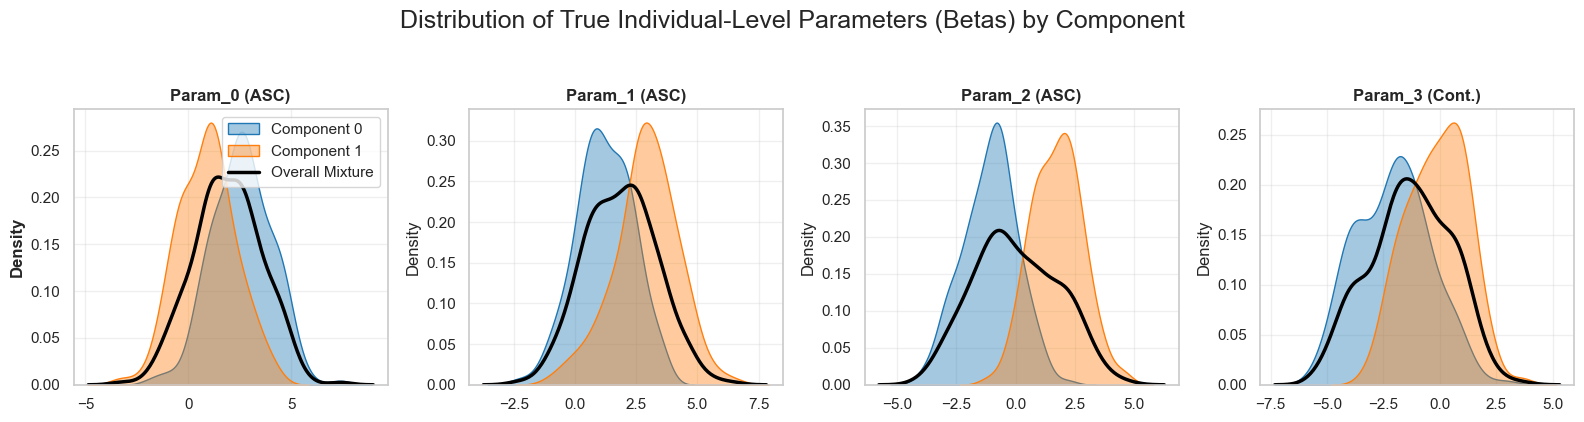

In [4]:
def plot_beta_mixture_distributions(betas, indicators, K, p_names):
    n_params_ = len(p_names)
    fig, axes = plt.subplots(1, n_params_, figsize=(4 * n_params_, 4))
    if n_params_ == 1:
        axes = [axes]
    colors = sns.color_palette("tab10", K)

    for p in range(n_params_):
        ax = axes[p]
        for k in range(K):
            comp = betas[indicators == k, p]
            if len(comp) > 1:
                sns.kdeplot(comp, ax=ax, fill=True, color=colors[k],
                            alpha=0.4, label=f"Component {k}")
        sns.kdeplot(betas[:, p], ax=ax, color="black", linewidth=2.5,
                    label="Overall Mixture")
        ax.set_title(p_names[p], fontweight="bold")
        ax.grid(True, alpha=0.3)
        if p == 0:
            ax.set_ylabel("Density", fontweight="bold")
            handles, labels = ax.get_legend_handles_labels()
            unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels))
                      if l not in labels[:i]]
            ax.legend(*zip(*unique), loc="upper right")

    plt.suptitle(
        "Distribution of True Individual-Level Parameters (Betas) by Component",
        fontsize=18, y=1.05
    )
    plt.tight_layout()
    plt.show()


plot_beta_mixture_distributions(
    betas=sim_data["TRUE_BETA"],
    indicators=sim_data["TRUE_INDICATORS"],
    K=K, p_names=param_names
)


In [5]:
def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, scale_tril=scale_tril,
        input_output_cholesky=True, validate_args=False
    )


def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )


def build_mixture_hmnl_model(data_dict, A_delta=0.01, a_mu=1.0):
    """
    Builds the Hierarchical MNL model with mixture-of-K-normals heterogeneity
    following Rossi et al. (2006) §5.5.
    """
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    K        = int(data_dict["K"])
    has_Z    = data_dict.get("Z") is not None

    nu        = float(n_params + 3)
    V_inv     = jnp.linalg.inv(nu * jnp.eye(n_params))
    Vinv_chol = jnp.linalg.cholesky(V_inv)
    Vinv_chol_K = jnp.broadcast_to(Vinv_chol[None], (K, n_params, n_params))

    # pvec ~ Dirichlet(alpha)
    alpha = jnp.ones(K) * 2.0
    pvec  = lsl.Var.new_param(
        value=jnp.ones(K) / K,
        distribution=lsl.Dist(tfd.Dirichlet, concentration=alpha),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    # Sigma_k^{-1} ~ Wishart(nu, V^{-1})
    sigma_inv_chol_k = lsl.Var.new_param(
        value=jnp.broadcast_to(jnp.eye(n_params)[None], (K, n_params, n_params)),
        distribution=lsl.Dist(
            make_wishart,
            df=jnp.full(K, nu),
            scale_tril=Vinv_chol_K
        ),
        name="sigma_inv_chol_k"
    )
    sigma_inv_chol_k_latent = sigma_inv_chol_k.transform(
        tfb.FillScaleTriL(), name="sigma_inv_chol_k_latent"
    )

    # mu_k ~ N(0, Sigma_k / a_mu)
    mu_prec_factor_k = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L,
        L=sigma_inv_chol_k,
        name="mu_prec_factor_k"
    )
    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision,
            loc=jnp.zeros(n_params),
            precision_factor=mu_prec_factor_k
        ),
        name="mu_k"
    )

    # Delta ~ N(0, A_delta^{-1} I)
    if has_Z:
        n_demos = data_dict["Z"].shape[1]
        Z_var   = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
        Delta_prec_factor = jnp.sqrt(A_delta) * jnp.eye(n_params)
        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_demos, n_params)),
            distribution=lsl.Dist(
                make_mvn_precision,
                loc=jnp.zeros(n_params),
                precision_factor=Delta_prec_factor
            ),
            name="Delta"
        )
        z_delta = lsl.Var.new_calc(
            lambda z, d: z @ d, z=Z_var, d=Delta, name="z_delta"
        )

    # Chol(Sigma_k) from Chol(Sigma_k^{-1})
    sigma_chol_k = lsl.Var.new_calc(
        lambda L: jax.vmap(
            lambda Lk: jnp.linalg.cholesky(
                jnp.linalg.inv(Lk @ Lk.T) + 1e-6 * jnp.eye(n_params)
            )
        )(L),
        L=sigma_inv_chol_k,
        name="sigma_chol_k"
    )

    # Marginal beta_i ~ sum_k pvec_k N(Delta'z_i + mu_k, Sigma_k)
    if has_Z:
        beta_loc = lsl.Var.new_calc(
            lambda zd, mu: zd[:, None, :] + mu[None, :, :],
            zd=z_delta, mu=mu_k, name="beta_loc"
        )
    else:
        beta_loc = lsl.Var.new_calc(
            lambda mu: jnp.broadcast_to(mu[None, :, :], (n_units, K, n_params)),
            mu=mu_k, name="beta_loc"
        )

    def make_beta_mixture(pvec, locs, scale_trils):
        return tfd.MixtureSameFamily(
            mixture_distribution=tfd.Categorical(probs=pvec),
            components_distribution=tfd.MultivariateNormalTriL(
                loc=locs,
                scale_tril=scale_trils[None]
            )
        )

    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture,
            pvec=pvec, locs=beta_loc, scale_trils=sigma_chol_k
        ),
        name="beta_i"
    )

    # Likelihood
    X_var   = lsl.Var.new_obs(data_dict["X"],        name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded"
    )
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b),
        x=X_var, b=beta_expanded, name="logits"
    )
    y_var = lsl.Var.new_obs(
        data_dict["y"],
        distribution=lsl.Dist(tfd.Categorical, logits=logits),
        name="y"
    )

    return lsl.Model([y_var])


In [6]:
def run_mixture_inference(
    model, data_dict, chains=4, warmup=1000, posterior=2000, seed=123
):
    """Runs NUTS inference for the mixture HMNL model."""
    has_Z = data_dict.get("Z") is not None

    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    eb.add_kernel(gs.NUTSKernel(["pvec_latent"]))
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_k_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel(["mu_k"]))
    if has_Z:
        eb.add_kernel(gs.NUTSKernel(["Delta"]))
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS Sampling — Mixture of Normals HMNL...")
    engine = eb.build()
    engine.sample_all_epochs()

    return engine.get_results(), engine.get_results().get_posterior_samples()


In [7]:
print("Building Mixture of Normals HMNL Model...")
choice_data = sim_data
hmnl_model  = build_mixture_hmnl_model(choice_data)

start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(
    hmnl_model, choice_data, chains=4, warmup=1000, posterior=2000
)
elapsed = str(datetime.timedelta(seconds=int(time.time() - start_time)))
print(f"Sampling finished in {elapsed}")


Building Mixture of Normals HMNL Model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling — Mixture of Normals HMNL...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:43<00:00, 14.35s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 1, 2, 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 6, 6, 5, 6 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2, 4, 2, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 1, 2, 1, 2 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_04: 2, 2, 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 283.94chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2, 1, 1, 1 / 25 transitions
liesel.goose.e

Sampling finished in 0:20:21


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# 5a.  CORE RELABELING ENGINE
#      Iterative pivotal reordering (Marin et al. 2005)
# ──────────────────────────────────────────────────────────────────────────────

def _best_permutation(mu_draw: np.ndarray, reference_mu: np.ndarray) -> np.ndarray:
    """
    Hungarian-algorithm optimal assignment of draw components to reference.
    cost[i,j] = ||reference_mu[i] - mu_draw[j]||^2
    Returns perm s.t. mu_draw[perm] ≈ reference_mu.
    """
    diff = reference_mu[:, None, :] - mu_draw[None, :, :]  # (K, K, P)
    cost = np.sum(diff ** 2, axis=-1)                       # (K, K)
    _, col_ind = linear_sum_assignment(cost)
    return col_ind


def relabel_mixture_samples(
    mu_samples:    np.ndarray,
    sigma_samples: np.ndarray,
    pvec_samples:  np.ndarray,
    n_iter:        int   = 20,
    tol:           float = 1e-8,
    verbose:       bool  = True,
) -> dict:
    """
    Post-process MCMC draws to resolve label switching via iterative
    pivotal reordering (Marin et al. 2005; Rossi et al. 2006 §5.5).

    Algorithm
    ---------
    1. Initialise reference  ξ* = mean_draws(mu_k)
    2. For every draw d, solve assignment: perm_d = argmin_σ Σ_k ||mu[d,σ(k)] - ξ*[k]||²
    3. Apply perm_d to mu_k[d], sigma_k[d], pvec[d].
    4. Update  ξ* = mean(mu_k_relabeled). Repeat until convergence.

    Parameters
    ----------
    mu_samples    : (n_draws, K, P)
    sigma_samples : (n_draws, K, P, P)
    pvec_samples  : (n_draws, K)
    n_iter        : max relabeling passes
    tol           : convergence threshold (sup-norm on reference)
    verbose       : print iteration info

    Returns
    -------
    dict: mu_k, sigma_k, pvec, permutations, reference_mu, n_iters_run
    """
    mu_samples    = np.asarray(mu_samples,    dtype=float)
    sigma_samples = np.asarray(sigma_samples, dtype=float)
    pvec_samples  = np.asarray(pvec_samples,  dtype=float)

    n_draws, K, P = mu_samples.shape

    mu_rl    = mu_samples.copy()
    sigma_rl = sigma_samples.copy()
    pvec_rl  = pvec_samples.copy()

    reference_mu   = mu_rl.mean(axis=0)   # (K, P) — initial reference
    converged_iter = n_iter

    if verbose:
        print(f"Starting pivotal relabeling  [{n_draws} draws, K={K}, P={P}]")

    for it in range(n_iter):
        perms = np.zeros((n_draws, K), dtype=int)
        for d in range(n_draws):
            perm        = _best_permutation(mu_rl[d], reference_mu)
            perms[d]    = perm
            mu_rl[d]    = mu_rl[d, perm, :]
            sigma_rl[d] = sigma_rl[d, perm, :, :]
            pvec_rl[d]  = pvec_rl[d, perm]

        new_reference = mu_rl.mean(axis=0)
        delta         = np.max(np.abs(new_reference - reference_mu))
        reference_mu  = new_reference

        if verbose:
            print(f"  Iter {it+1:3d}: max |Δ reference| = {delta:.2e}")

        if delta < tol:
            converged_iter = it + 1
            if verbose:
                print(f"  Converged at iteration {converged_iter}.")
            break

    return {
        "mu_k":         mu_rl,
        "sigma_k":      sigma_rl,
        "pvec":         pvec_rl,
        "permutations": perms,
        "reference_mu": reference_mu,
        "n_iters_run":  converged_iter,
    }


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# 5b.  IDENTIFIED MOMENTS  (bayesm momMix equivalent)
# ──────────────────────────────────────────────────────────────────────────────

def compute_mixture_moments(
    mu_rl:    np.ndarray,
    sigma_rl: np.ndarray,
    pvec_rl:  np.ndarray,
) -> dict:
    """
    Average the identified moments of the normal mixture over MCMC draws.

    For a mixture Σ_k w_k N(μ_k, Σ_k):
        E[β]   = Σ_k w_k μ_k
        Var[β] = Σ_k w_k Σ_k  +  Σ_k w_k (μ_k − E[β])(μ_k − E[β])'

    Both quantities are label-invariant. We return the posterior mean of
    each across all draws, mirroring bayesm's momMix() logic.

    Returns
    -------
    dict: mean_beta (P,), var_beta (P,P), sd_beta (P,), corr_beta (P,P)
    """
    n_draws, K, P = mu_rl.shape
    mean_accum    = np.zeros(P)
    var_accum     = np.zeros((P, P))

    for d in range(n_draws):
        w      = pvec_rl[d]
        mu     = mu_rl[d]
        sig    = sigma_rl[d]
        E_beta = (w[:, None] * mu).sum(axis=0)
        diff   = mu - E_beta[None, :]
        var_d  = (w[:, None, None] * sig).sum(axis=0)
        var_d += (w[:, None, None] * (diff[:, :, None] * diff[:, None, :])).sum(axis=0)
        mean_accum += E_beta
        var_accum  += var_d

    E_post   = mean_accum / n_draws
    Var_post = var_accum  / n_draws
    sd       = np.sqrt(np.diag(Var_post))
    d_inv    = np.where(sd > 0, 1.0 / sd, 0.0)
    corr     = d_inv[:, None] * Var_post * d_inv[None, :]

    return {"mean_beta": E_post, "var_beta": Var_post,
            "sd_beta": sd, "corr_beta": corr}


In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# 5c.  FULL PIPELINE WRAPPER
# ──────────────────────────────────────────────────────────────────────────────

def postprocess_mixture_posterior(
    posterior_samples: dict,
    choice_data:       dict,
    bijector_pvec,
    bijector_sigma,
    n_iter:  int  = 20,
    verbose: bool = True,
) -> dict:
    """
    End-to-end post-processing:
      1. Recovers Sigma_k from latent FillScaleTriL Cholesky parameterisation
      2. Flattens (chains × draws) for all parameters
      3. Runs iterative pivotal reordering to fix label switching
      4. Computes identified mixture moments (momMix equivalent)

    Returns
    -------
    dict: mu_k, sigma_k, pvec, Delta, beta_i, permutations,
          mixture_moments, raw_mu_k, raw_sigma_k, raw_pvec, n_draws
    """
    K = int(choice_data["K"])
    P = int(choice_data["n_params"])
    D = int(choice_data["n_demos"])

    # 1. Recover Sigma_k from latent Cholesky factors
    print("Recovering Sigma_k from latent Cholesky factors...")

    def latent_to_sigma_single(latent_vec):
        L             = bijector_sigma.forward(latent_vec)
        precision_mat = np.array(L) @ np.array(L).T
        return np.linalg.inv(precision_mat + 1e-6 * np.eye(P))

    latent_raw  = np.array(posterior_samples["sigma_inv_chol_k_latent"])
    chains, draws, _, latent_dim = latent_raw.shape
    latent_flat = latent_raw.reshape(-1, K, latent_dim)
    n_draws     = latent_flat.shape[0]

    sigma_flat = np.zeros((n_draws, K, P, P))
    for d in range(n_draws):
        for k in range(K):
            sigma_flat[d, k] = latent_to_sigma_single(latent_flat[d, k])

    # 2. Flatten mu_k and pvec
    mu_raw   = np.array(posterior_samples["mu_k"]).reshape(n_draws, K, P)
    pvec_raw = np.array(
        bijector_pvec.forward(posterior_samples["pvec_latent"])
    ).reshape(n_draws, K)

    # 3. Relabeling
    print("\nRelabeling mixture component samples...")
    rl = relabel_mixture_samples(
        mu_samples=mu_raw, sigma_samples=sigma_flat,
        pvec_samples=pvec_raw, n_iter=n_iter, verbose=verbose,
    )

    # 4. Identified moments
    print("\nComputing identified mixture moments (momMix equivalent)...")
    mix_moments = compute_mixture_moments(rl["mu_k"], rl["sigma_k"], rl["pvec"])

    # 5. Flatten Delta and beta_i (no K dimension — label switching does not apply)
    delta_flat = np.array(posterior_samples["Delta"]).reshape(n_draws, D, P)
    n_chains_r, n_post_r, n_units_r, _ = posterior_samples["beta_i"].shape
    beta_flat  = np.array(posterior_samples["beta_i"]).reshape(n_draws, n_units_r, P)

    return {
        "mu_k":            rl["mu_k"],
        "sigma_k":         rl["sigma_k"],
        "pvec":            rl["pvec"],
        "Delta":           delta_flat,
        "beta_i":          beta_flat,
        "permutations":    rl["permutations"],
        "reference_mu":    rl["reference_mu"],
        "mixture_moments": mix_moments,
        "raw_mu_k":        mu_raw,
        "raw_sigma_k":     sigma_flat,
        "raw_pvec":        pvec_raw,
        "n_draws":         n_draws,
    }


In [11]:
bijector_pvec  = tfb.SoftmaxCentered()
bijector_sigma = tfb.FillScaleTriL()

print("Running label-switching post-processing...")
pp = postprocess_mixture_posterior(
    posterior_samples = posterior_samples,
    choice_data       = choice_data,
    bijector_pvec     = bijector_pvec,
    bijector_sigma     = bijector_sigma,
    n_iter            = 20,
    verbose           = True,
)

# ── Convenience aliases ────────────────────────────────────────────────────────
n_draws          = pp["n_draws"]
mu_samples       = pp["mu_k"]            # (n_draws, K, P)   RELABELED
sigma_samples    = pp["sigma_k"]         # (n_draws, K, P, P) RELABELED
pvec_samples     = pp["pvec"]           # (n_draws, K)        RELABELED
delta_samples    = pp["Delta"]           # (n_draws, D, P)     unchanged
liesel_beta_full = pp["beta_i"]          # (n_draws, N, P)     unchanged
mix_moments      = pp["mixture_moments"] # label-invariant moments

true_mu_k    = choice_data["TRUE_MU_K"]
true_pvec    = choice_data["TRUE_PVEC"]
true_delta   = choice_data["TRUE_DELTA"]
true_betas   = choice_data["TRUE_BETA"]
n_units_     = liesel_beta_full.shape[1]

print(f"\nPost-processing complete. n_draws={n_draws}")
print(f"Sample permutations (first 5 draws):\n{pp['permutations'][:5]}")


Running label-switching post-processing...
Recovering Sigma_k from latent Cholesky factors...

Relabeling mixture component samples...
Starting pivotal relabeling  [8000 draws, K=2, P=4]
  Iter   1: max |Δ reference| = 6.22e-01
  Iter   2: max |Δ reference| = 0.00e+00
  Converged at iteration 2.

Computing identified mixture moments (momMix equivalent)...

Post-processing complete. n_draws=8000
Sample permutations (first 5 draws):
[[0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]]


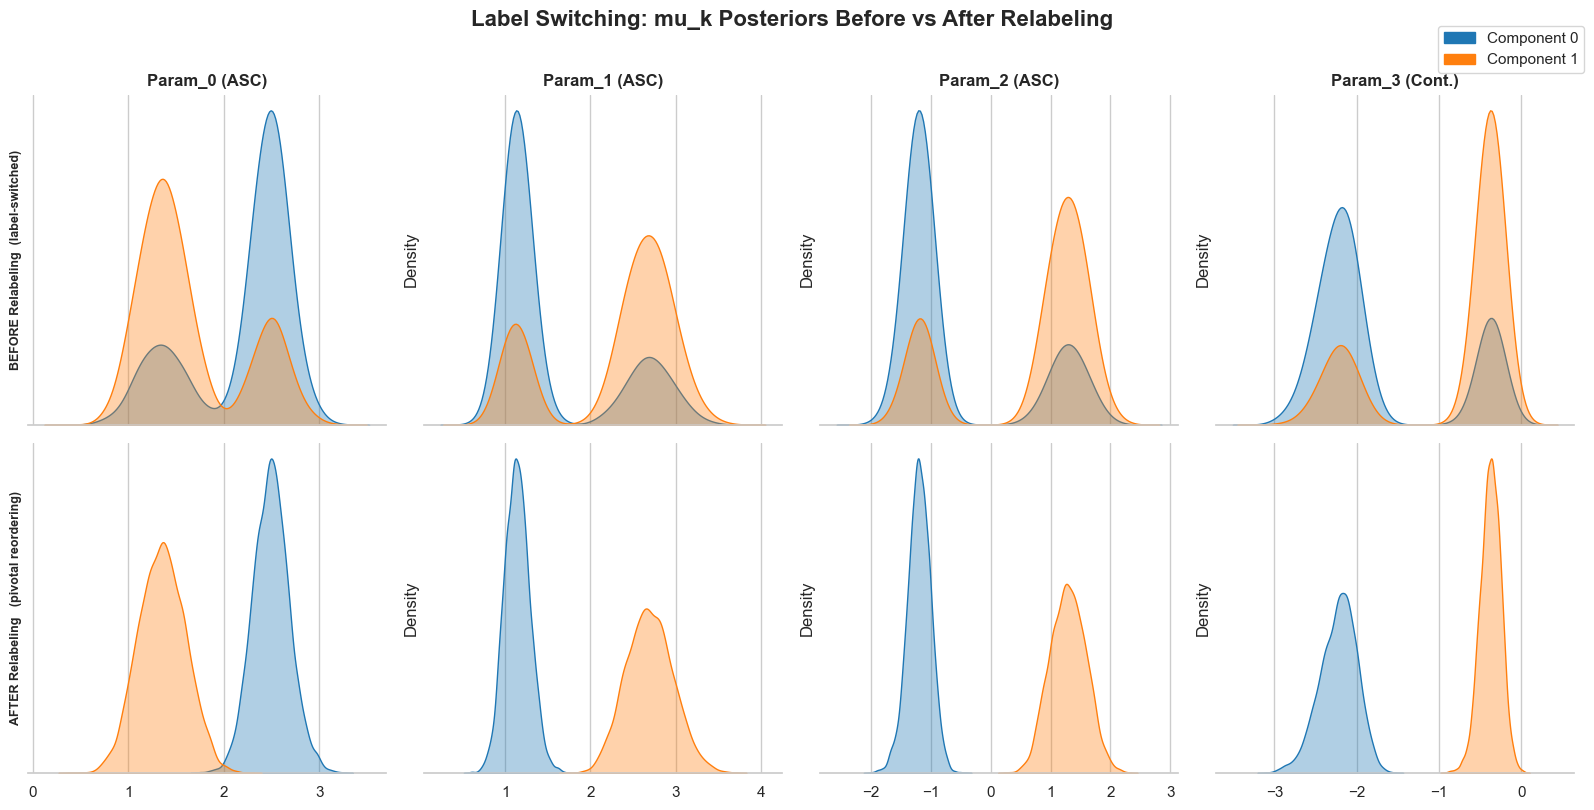

In [12]:
def plot_label_switching_comparison(raw_mu, rl_mu, K, param_names):
    """
    Side-by-side KDE of mu_k posteriors before and after relabeling.
    The 'hairball' of overlapping components should collapse into
    well-separated modes after pivotal reordering.
    """
    P_     = raw_mu.shape[2]
    colors = sns.color_palette("tab10", K)
    fig, axes = plt.subplots(2, P_, figsize=(4 * P_, 8), sharex="col")

    for p in range(P_):
        for panel, (data, title) in enumerate([
            (raw_mu, "BEFORE Relabeling  (label-switched)"),
            (rl_mu,  "AFTER Relabeling   (pivotal reordering)"),
        ]):
            ax = axes[panel, p]
            for k in range(K):
                sns.kdeplot(data[:, k, p], ax=ax, color=colors[k],
                            fill=True, alpha=0.35, label=f"Comp {k}")
            if panel == 0:
                ax.set_title(param_names[p], fontweight="bold")
            if p == 0:
                ax.set_ylabel(title, fontsize=9, fontweight="bold")
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)

    handles = [
        plt.matplotlib.patches.Patch(color=colors[k], label=f"Component {k}")
        for k in range(K)
    ]
    fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.0, 1.0))
    plt.suptitle(
        "Label Switching: mu_k Posteriors Before vs After Relabeling",
        fontsize=16, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()


plot_label_switching_comparison(
    raw_mu=pp["raw_mu_k"], rl_mu=pp["mu_k"],
    K=K, param_names=param_names
)


In [13]:
print("=== MCMC Convergence Summary ===")
summary = gs.Summary(mcmc_results)

=== MCMC Convergence Summary ===


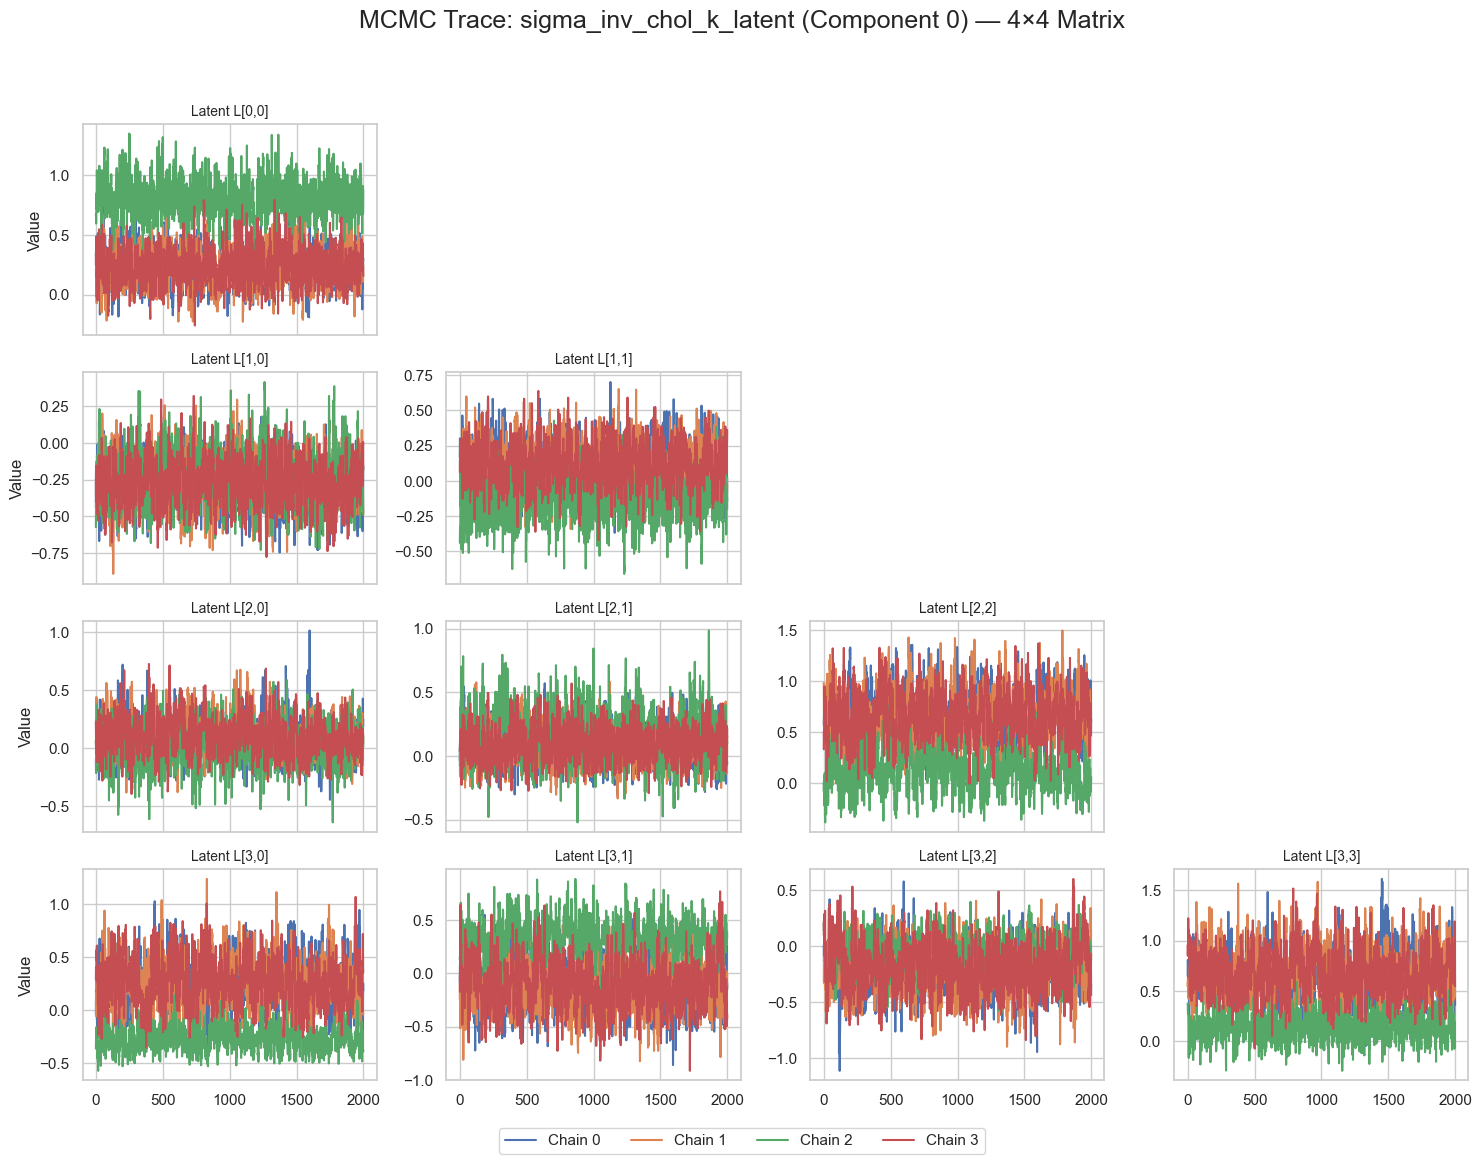

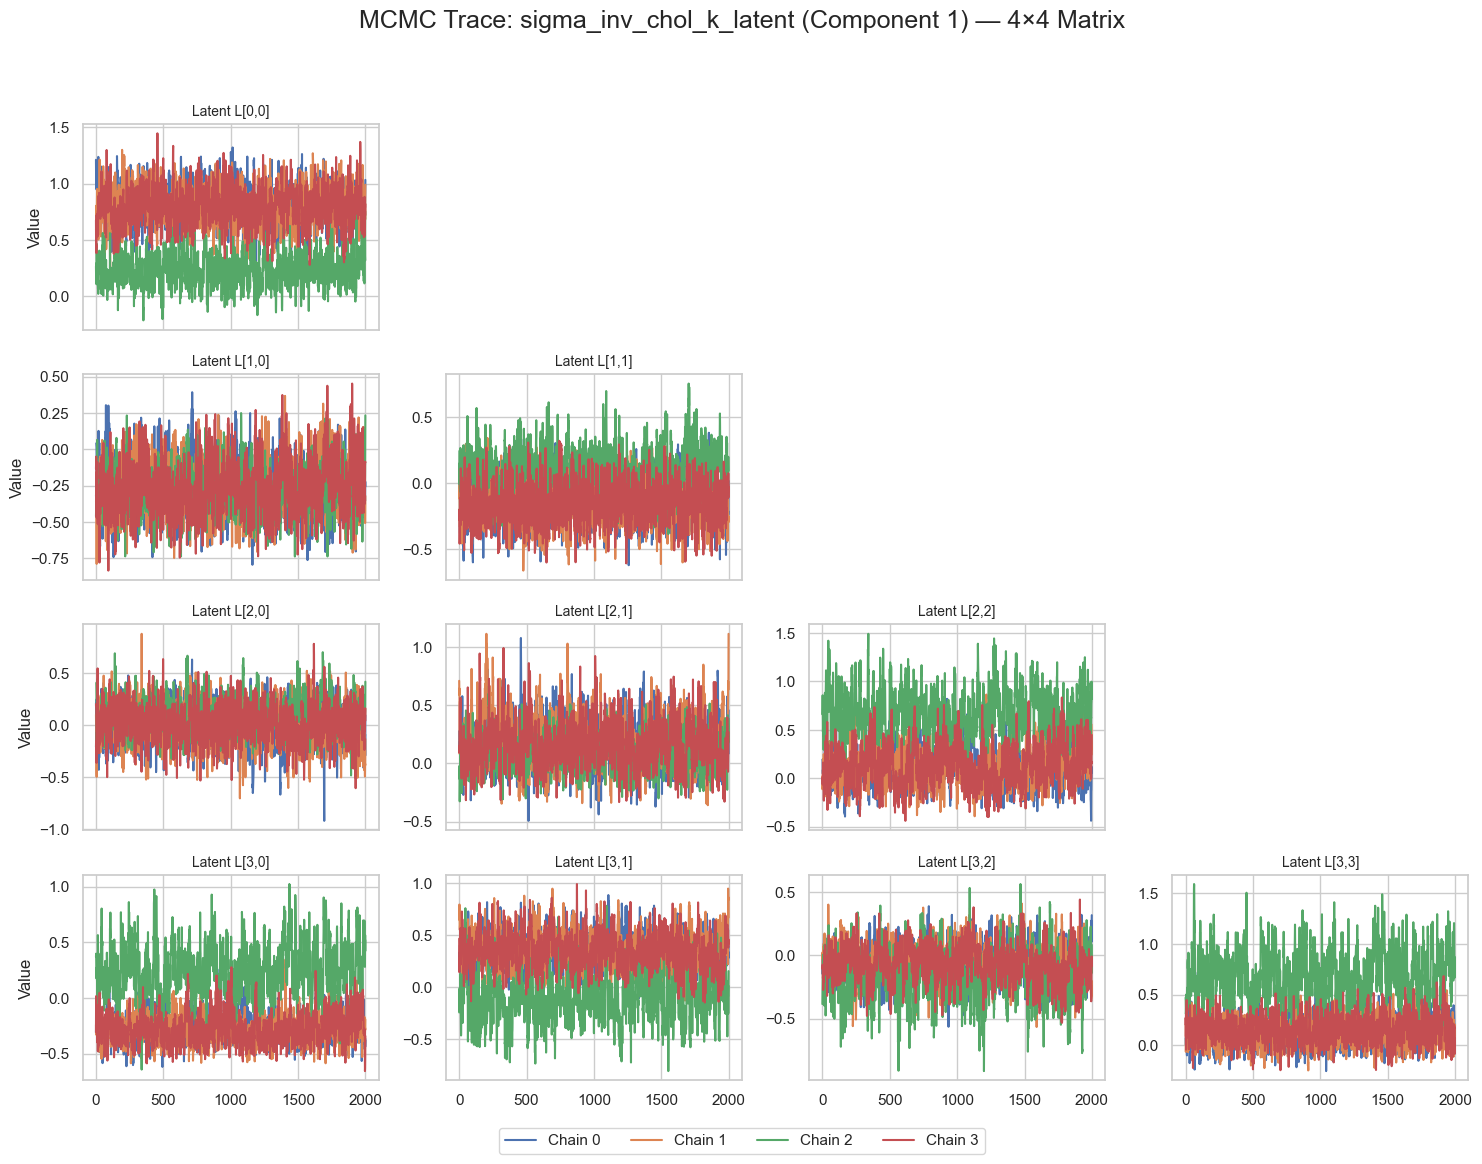

In [14]:
def plot_cholesky_traces(
    samples_dict, n_params, k_idx=0,
    param_name="sigma_inv_chol_k_latent", figsize=(15, 12)
):
    latent_samples = samples_dict[param_name][:, :, k_idx, :]
    n_chains_, n_draws_, n_latent = latent_samples.shape

    fig, axes = plt.subplots(n_params, n_params, figsize=figsize,
                             sharex=True, sharey=False)
    if n_params == 1:
        axes = np.array([[axes]])

    latent_idx = 0
    for i in range(n_params):
        for j in range(n_params):
            ax = axes[i, j]
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains_):
                    ax.plot(latent_samples[chain, :, latent_idx],
                            label=f"Chain {chain}")
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                ax.axis("off")
            ax.grid(True)
            if j == 0:
                ax.set_ylabel("Value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=n_chains_,
               bbox_to_anchor=(0.5, 0.02))
    plt.suptitle(
        f"MCMC Trace: {param_name} (Component {k_idx}) — {n_params}×{n_params} Matrix",
        fontsize=18
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


for k in range(K):
    plot_cholesky_traces(posterior_samples, n_params=P, k_idx=k)


=== Detailed Delta Parameter Diagnostics (Goose Style) ===


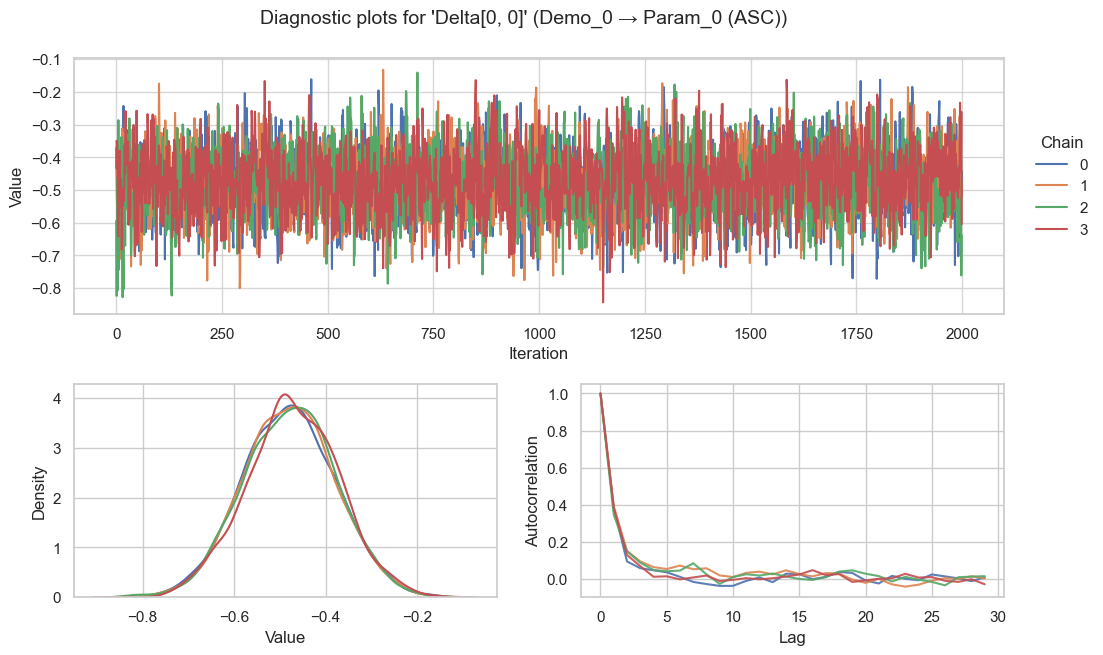

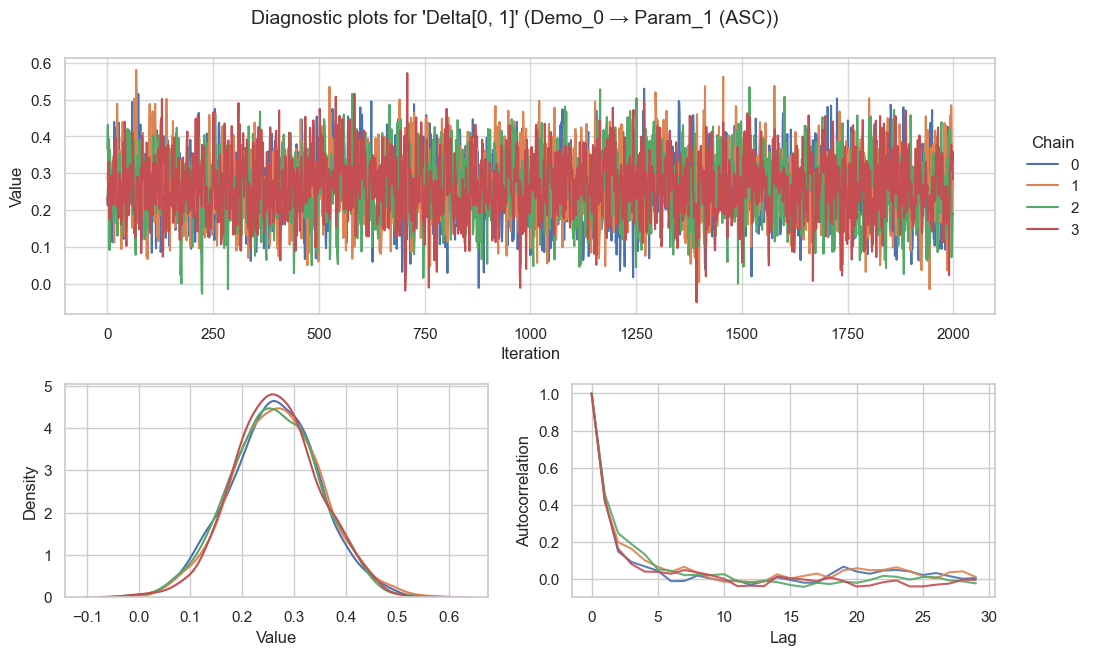

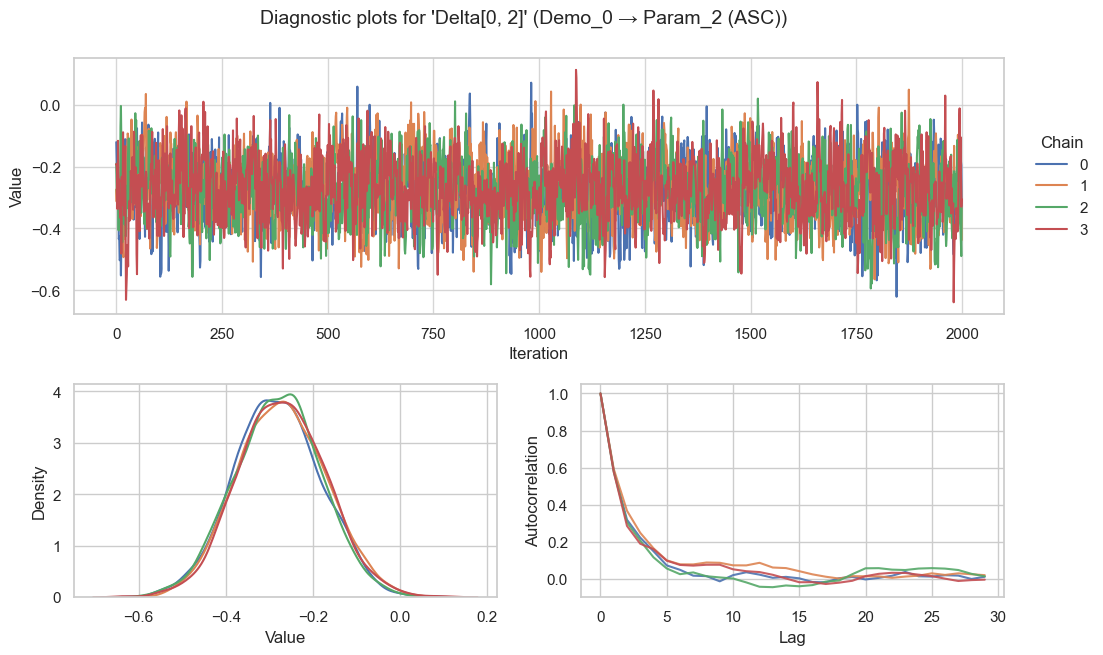

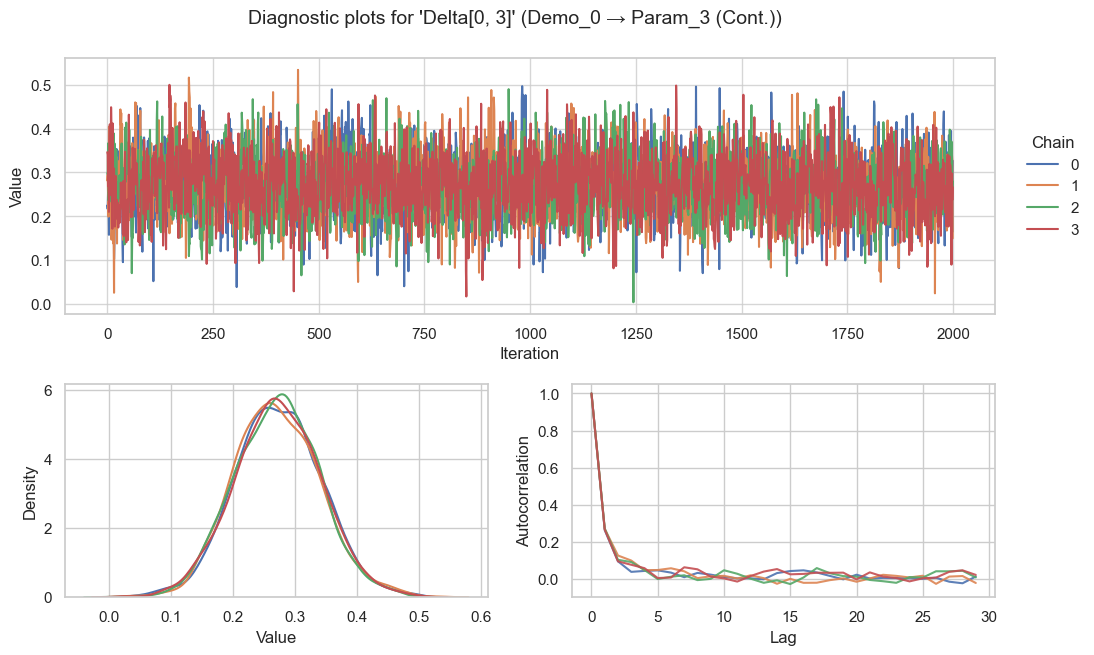

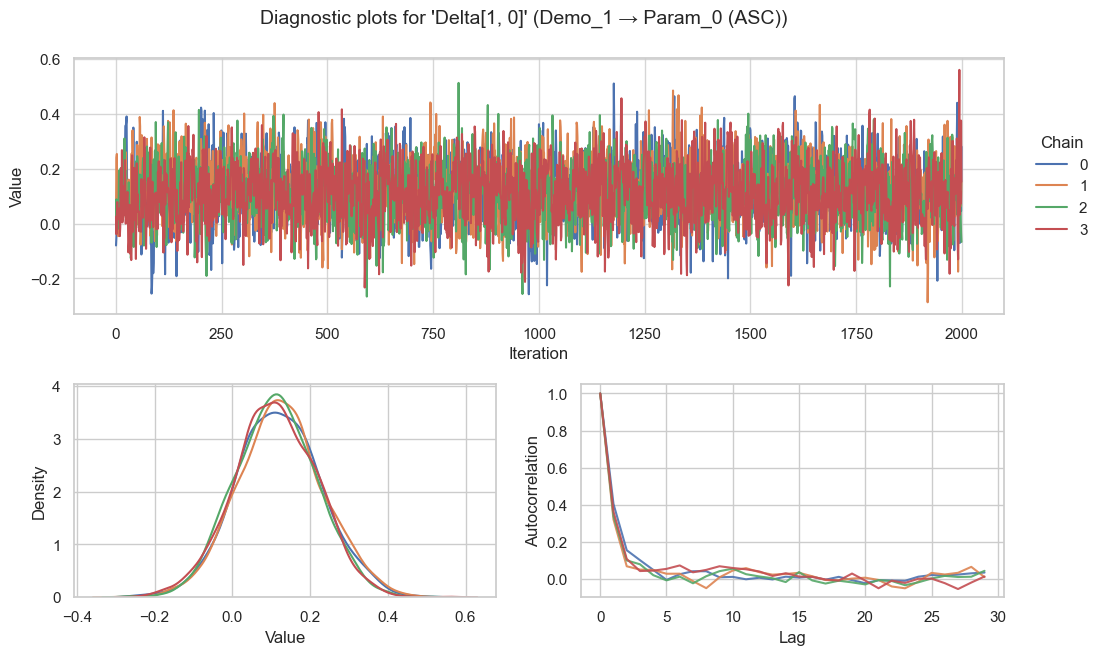

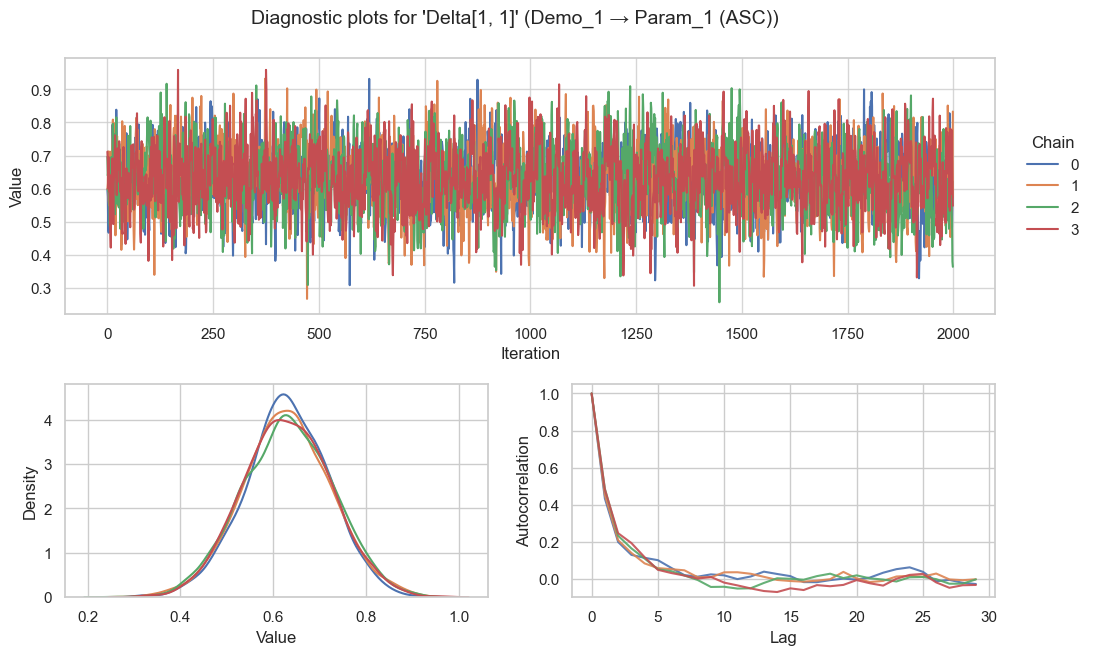

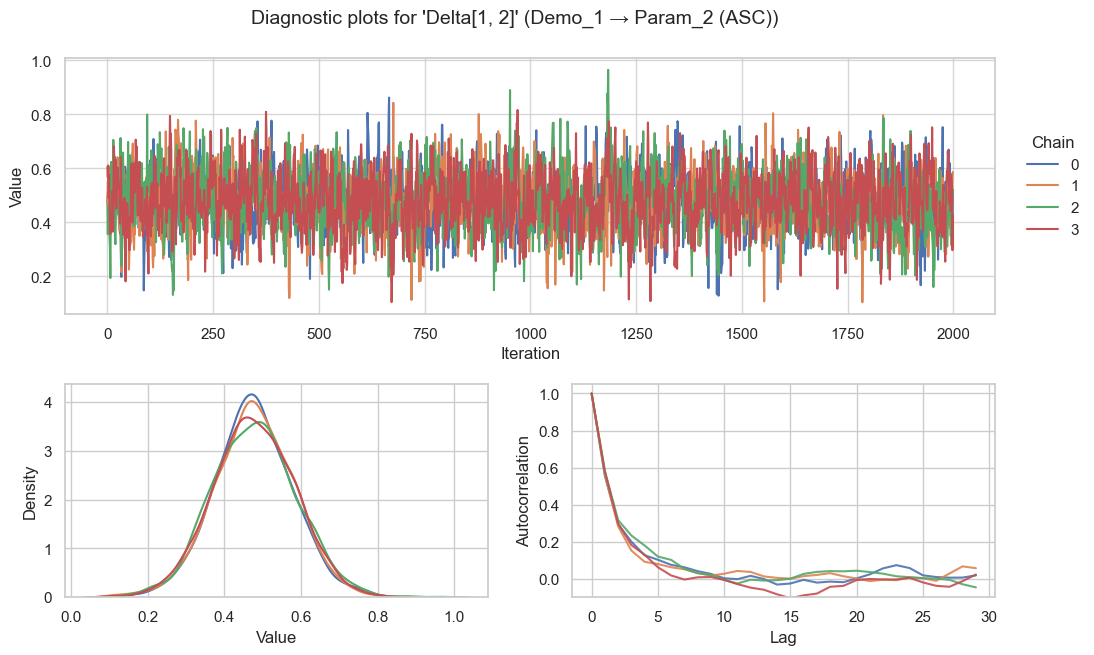

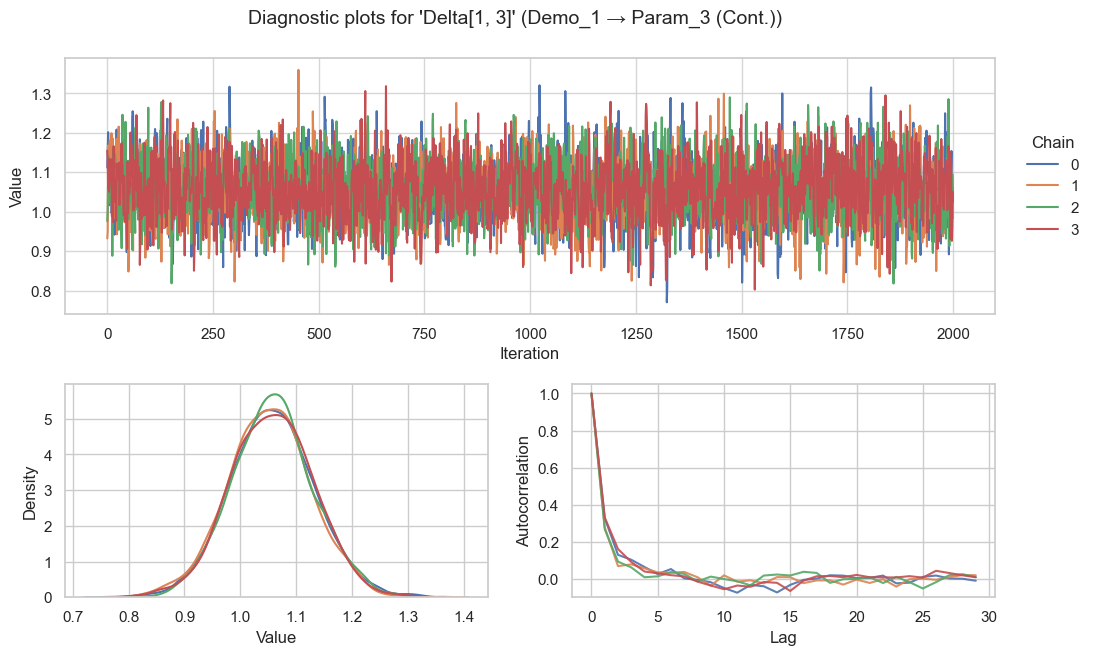

In [15]:
def compute_acf(x, nlags=30):
    x_c  = x - np.mean(x)
    norm = np.sum(x_c ** 2)
    if norm == 0:
        return np.zeros(nlags)
    acf = np.correlate(x_c, x_c, mode="full")
    acf = acf[acf.size // 2:] / norm
    return acf[:nlags]


def plot_goose_style_diagnostics(
    delta_array, demo_idx, param_idx,
    demo_name, param_name, n_lags=30
):
    n_chains_ = delta_array.shape[0]
    fig = plt.figure(figsize=(12, 7))
    fig.suptitle(
        f"Diagnostic plots for 'Delta[{demo_idx}, {param_idx}]' "
        f"({demo_name} → {param_name})",
        fontsize=14, y=0.95
    )
    gs_layout = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1],
                                  hspace=0.3, wspace=0.2)

    ax_trace = fig.add_subplot(gs_layout[0, :])
    for chain in range(n_chains_):
        ax_trace.plot(delta_array[chain, :, demo_idx, param_idx],
                      label=str(chain))
    ax_trace.set_xlabel("Iteration")
    ax_trace.set_ylabel("Value")
    ax_trace.grid(True, alpha=0.8)
    ax_trace.legend(title="Chain", loc="center left",
                    bbox_to_anchor=(1.02, 0.5), frameon=False)

    ax_dens = fig.add_subplot(gs_layout[1, 0])
    for chain in range(n_chains_):
        sns.kdeplot(delta_array[chain, :, demo_idx, param_idx],
                    ax=ax_dens, fill=False)
    ax_dens.set_xlabel("Value")
    ax_dens.set_ylabel("Density")
    ax_dens.grid(True)

    ax_acf = fig.add_subplot(gs_layout[1, 1])
    for chain in range(n_chains_):
        acf_vals = compute_acf(
            delta_array[chain, :, demo_idx, param_idx], nlags=n_lags
        )
        ax_acf.plot(acf_vals, alpha=0.9)
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.set_ylim(-0.1, 1.05)
    ax_acf.grid(True)

    plt.show()


print("=== Detailed Delta Parameter Diagnostics (Goose Style) ===")
raw_delta_for_diag = posterior_samples["Delta"]   # (chains, draws, D, P)
for i in range(D):
    for j in range(P):
        plot_goose_style_diagnostics(
            raw_delta_for_diag,
            demo_idx=i, param_idx=j,
            demo_name=demo_names[i], param_name=param_names[j]
        )


In [16]:
def create_summary_table(t_mu, post_mu, p_names):
    return pd.DataFrame({
        "Parameter":      p_names,
        "True_Value":     t_mu,
        "Posterior_Mean": post_mu.mean(axis=0),
        "Diff_Abs":       np.abs(t_mu - post_mu.mean(axis=0)),
        "Posterior_Std":  post_mu.std(axis=0),
    }).round(4).set_index("Parameter")


print("=== Component Baseline Means (mu_k) — post relabeling ===")
for k in range(K):
    print(f"\n--- Component {k} ---")
    display(create_summary_table(
        true_mu_k[k],
        mu_samples[:, k, :],
        [f"Param_{j}" for j in range(P)]
    ))


=== Component Baseline Means (mu_k) — post relabeling ===

--- Component 0 ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,2.5266,2.4931,0.0335,0.1930
Param_1,1.0739,1.1366,0.0626,0.1498
Param_2,-1.2251,-1.2033,0.0217,0.1940
Param_3,-2.0395,-2.2269,0.1874,0.2267



--- Component 1 ---


,True_Value,Posterior_Mean,Diff_Abs,Posterior_Std
Parameter,,,,
Param_0,1.0687,1.3538,0.2851,0.2472
Param_1,2.6586,2.6909,0.0322,0.2761
Param_2,1.7922,1.2893,0.5028,0.3009
Param_3,-0.2600,-0.3786,0.1186,0.1270


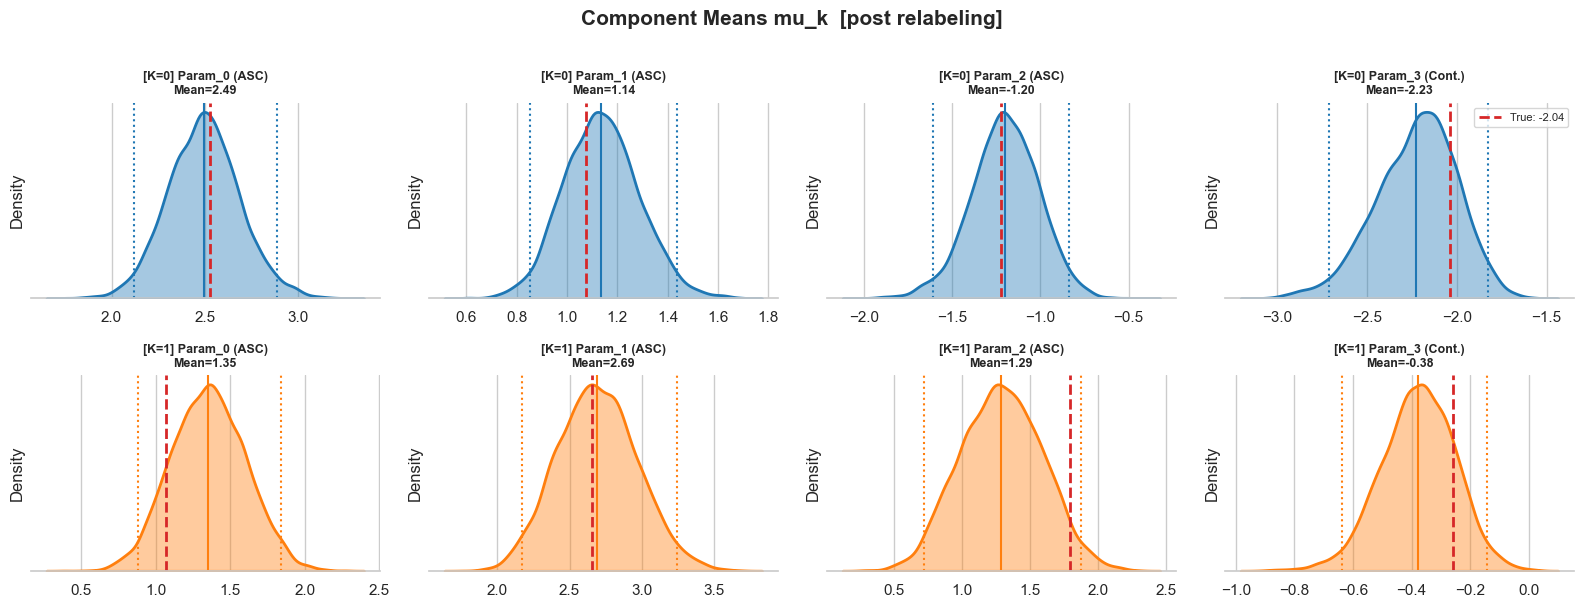

In [17]:
# ── mu_k KDE plots (relabeled) ────────────────────────────────────────────────
def plot_mu_k_relabeled(mu_rl, true_mu_k=None, param_names=None, figsize_per=(4, 3)):
    n_draws_, K_, P_ = mu_rl.shape
    if param_names is None:
        param_names = [f"Param_{p}" for p in range(P_)]
    colors = sns.color_palette("tab10", K_)
    fig, axes = plt.subplots(K_, P_,
                             figsize=(figsize_per[0] * P_, figsize_per[1] * K_))
    if K_ == 1: axes = axes[np.newaxis, :]
    if P_ == 1: axes = axes[:, np.newaxis]

    for k in range(K_):
        for p in range(P_):
            ax       = axes[k, p]
            samples  = mu_rl[:, k, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
            pm = np.mean(samples)
            sns.kdeplot(samples, ax=ax, fill=True, color=colors[k], alpha=0.4, lw=2)
            ax.axvline(pm,      color=colors[k], linestyle="-",  lw=1.5)
            ax.axvline(ci_low,  color=colors[k], linestyle=":",  lw=1.5)
            ax.axvline(ci_high, color=colors[k], linestyle=":",  lw=1.5)
            if true_mu_k is not None:
                tv = true_mu_k[k, p]
                ax.axvline(tv, color="#D62728", linestyle="--", lw=2,
                           label=f"True: {tv:.2f}")
            ax.set_title(f"[K={k}] {param_names[p]}\nMean={pm:.2f}",
                         fontsize=9, fontweight="bold")
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            if k == 0 and p == P_ - 1:
                ax.legend(fontsize=8, loc="upper right")

    plt.suptitle("Component Means mu_k  [post relabeling]",
                 fontsize=15, y=1.01, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_mu_k_relabeled(mu_rl=mu_samples, true_mu_k=true_mu_k, param_names=param_names)


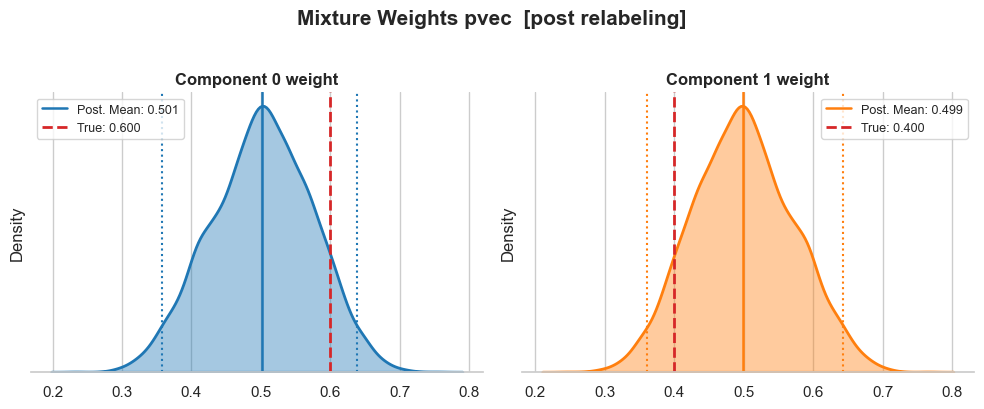

In [18]:
def plot_pvec_relabeled(pvec_rl, true_pvec=None):
    n_draws_, K_ = pvec_rl.shape
    colors = sns.color_palette("tab10", K_)
    fig, axes = plt.subplots(1, K_, figsize=(5 * K_, 4))
    if K_ == 1: axes = [axes]

    for k in range(K_):
        ax = axes[k]
        samples = pvec_rl[:, k]
        ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
        pm = np.mean(samples)
        sns.kdeplot(samples, ax=ax, fill=True, color=colors[k], alpha=0.4, lw=2)
        ax.axvline(pm,      color=colors[k], linestyle="-",  lw=1.8,
                   label=f"Post. Mean: {pm:.3f}")
        ax.axvline(ci_low,  color=colors[k], linestyle=":",  lw=1.5)
        ax.axvline(ci_high, color=colors[k], linestyle=":",  lw=1.5)
        if true_pvec is not None:
            tv = true_pvec[k]
            ax.axvline(tv, color="#D62728", linestyle="--", lw=2,
                       label=f"True: {tv:.3f}")
        ax.set_title(f"Component {k} weight", fontweight="bold")
        ax.legend(fontsize=9)
        ax.set_yticks([])
        sns.despine(ax=ax, left=True)

    plt.suptitle("Mixture Weights pvec  [post relabeling]",
                 fontsize=15, y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_pvec_relabeled(pvec_rl=pvec_samples, true_pvec=true_pvec)


In [19]:
def generate_delta_table(delta_draws, p_names, d_names):
    mean = np.mean(delta_draws, axis=0)
    std  = np.std(delta_draws,  axis=0)
    df   = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i,j]: .2f} ({std[i,j]:.2f})"
    return df


def generate_delta_diff_table(t_delta, l_delta, p_names, d_names):
    diff = np.abs(t_delta - np.mean(l_delta, axis=0))
    df   = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{diff[i,j]: .3f}"
    return df


pnames_ = [f"Param_{j}" for j in range(P)]
print("=== True Delta (Ground Truth) ===")
display(pd.DataFrame(true_delta, index=demo_names, columns=pnames_))

print("\n=== Posterior Delta — Mean (Std) ===")
display(generate_delta_table(delta_samples, pnames_, demo_names))

print("\n=== |True − Posterior| Absolute Difference ===")
display(generate_delta_diff_table(true_delta, delta_samples, pnames_, demo_names))


=== True Delta (Ground Truth) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.580527,0.169638,-0.448530,0.216387
Demo_1,-0.140216,0.507267,0.458458,1.059377



=== Posterior Delta — Mean (Std) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,-0.48 (0.10),0.27 (0.09),-0.28 (0.10),0.27 (0.07)
Demo_1,0.12 (0.11),0.63 (0.09),0.48 (0.11),1.06 (0.07)



=== |True − Posterior| Absolute Difference ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.104,0.096,0.173,0.055
Demo_1,0.258,0.123,0.019,0.003


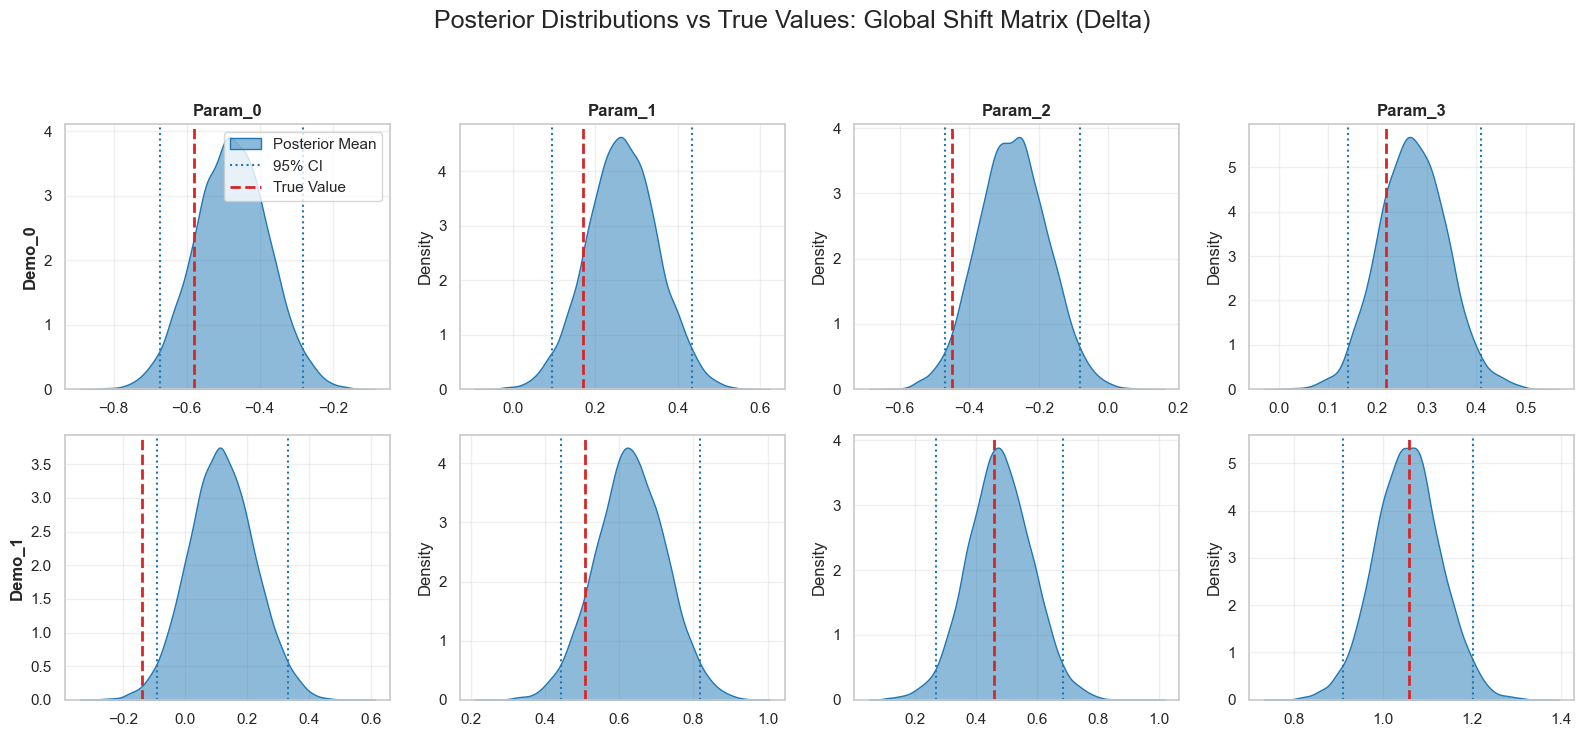

In [20]:
def plot_delta_distributions(delta_draws, t_delta, p_names, d_names):
    n_d = len(d_names)
    n_p = len(p_names)
    fig, axes = plt.subplots(n_d, n_p, figsize=(4 * n_p, 3.5 * n_d))

    for d in range(n_d):
        for p in range(n_p):
            ax = axes[d, p] if n_d > 1 else axes[p]
            samples = delta_draws[:, d, p]
            t_val   = t_delta[d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])

            sns.kdeplot(samples, ax=ax, fill=True,
                        color="#1f77b4", alpha=0.5, label="Posterior Mean")
            ax.axvline(ci_low,  color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)
            ax.axvline(t_val,   color="#D62728", linestyle="--", lw=2,  label="True Value")

            if d == 0: ax.set_title(p_names[p], fontweight="bold")
            if p == 0: ax.set_ylabel(d_names[d], fontweight="bold")
            ax.grid(True, alpha=0.3)

            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels))
                          if l not in labels[:i]]
                ax.legend(*zip(*unique), loc="upper right")

    plt.suptitle(
        "Posterior Distributions vs True Values: Global Shift Matrix (Delta)",
        fontsize=18, y=1.05
    )
    plt.tight_layout()
    plt.show()


plot_delta_distributions(delta_samples, true_delta, pnames_, demo_names)


In [21]:
def print_mommix_summary(mix_moments, true_beta_mean=None):
    E  = mix_moments["mean_beta"]
    sd = mix_moments["sd_beta"]
    P_ = len(E)

    rows = {"Post. Mean E[β]": E, "Post. Std SD[β]": sd}
    if true_beta_mean is not None:
        rows["True E[β]"]  = true_beta_mean
        rows["|Diff|"]     = np.abs(true_beta_mean - E)

    df = pd.DataFrame(rows, index=[f"Param_{p}" for p in range(P_)]).T
    print("=== Identified Mixture Moments (momMix equivalent) ===")
    print("(These quantities are invariant to label switching)\n")
    print(df.round(4).to_string())

    print("\n--- Posterior Correlation of β (from mixture) ---")
    corr_df = pd.DataFrame(
        mix_moments["corr_beta"].round(3),
        index=[f"P{p}" for p in range(P_)],
        columns=[f"P{p}" for p in range(P_)],
    )
    print(corr_df.to_string())


true_beta_mean = np.mean(choice_data["TRUE_BETA"], axis=0)
print_mommix_summary(mix_moments, true_beta_mean)


=== Identified Mixture Moments (momMix equivalent) ===
(These quantities are invariant to label switching)

                 Param_0  Param_1  Param_2  Param_3
Post. Mean E[β]   1.9360   1.8977   0.0307  -1.2983
Post. Std SD[β]   1.5954   1.4877   1.7509   1.4105
True E[β]         1.9081   1.8679   0.0319  -1.3033
|Diff|            0.0279   0.0298   0.0012   0.0050

--- Posterior Correlation of β (from mixture) ---
       P0     P1     P2     P3
P0  1.000 -0.176 -0.395 -0.305
P1 -0.176  1.000  0.477  0.332
P2 -0.395  0.477  1.000  0.593
P3 -0.305  0.332  0.593  1.000


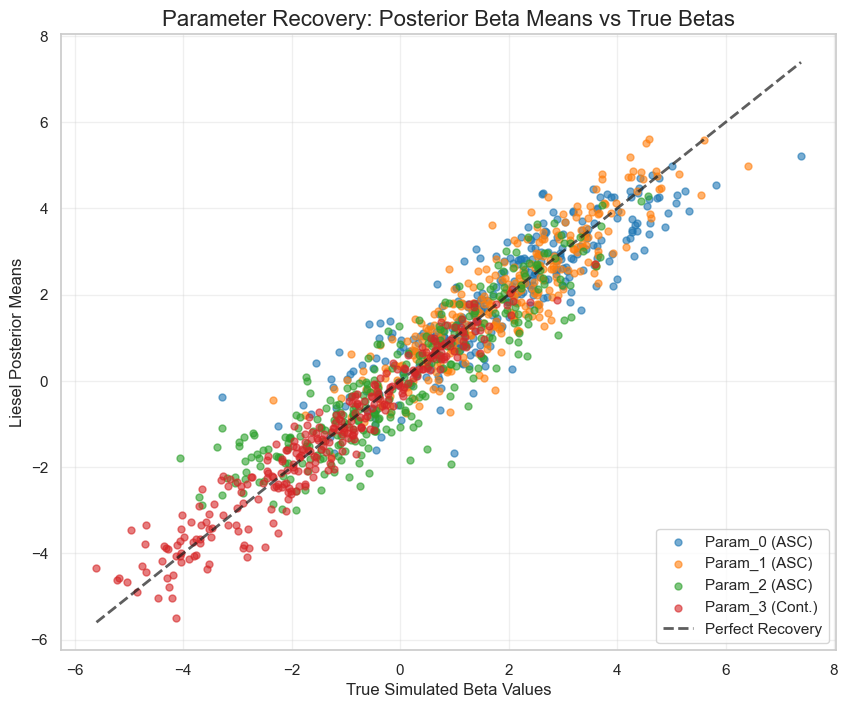

In [22]:
l_beta_means = np.mean(liesel_beta_full, axis=0)   # (N, P)
colors_      = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"][:P]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for i, pname in enumerate(param_names):
    ax.scatter(true_betas[:, i], l_beta_means[:, i],
               alpha=0.6, s=25, label=pname, color=colors_[i])

lo = min(true_betas.min(), l_beta_means.min())
hi = max(true_betas.max(), l_beta_means.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=2, alpha=0.7, label="Perfect Recovery")
ax.set_title("Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values", fontsize=12)
ax.set_ylabel("Liesel Posterior Means", fontsize=12)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.show()


Plotting Household-Level Distributions...


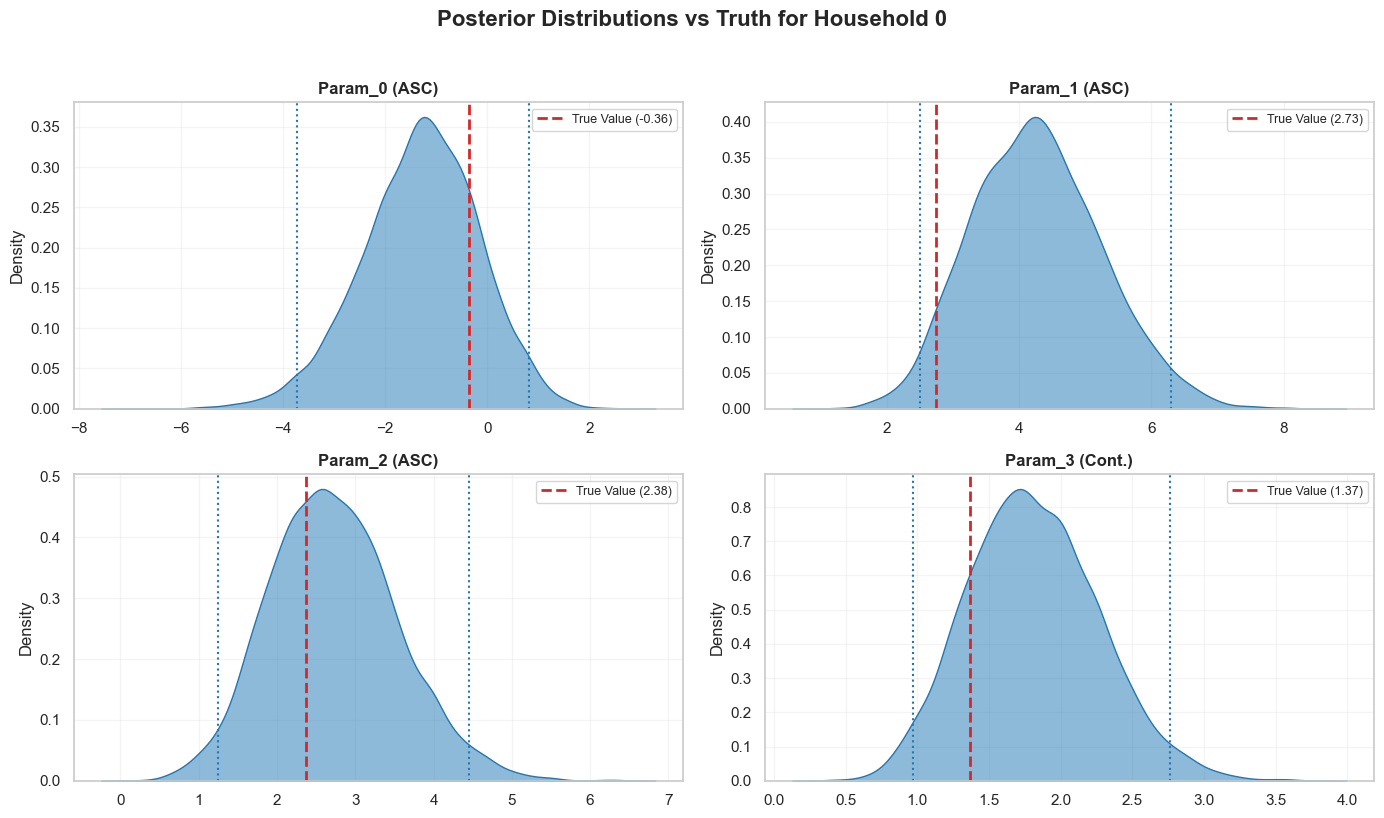

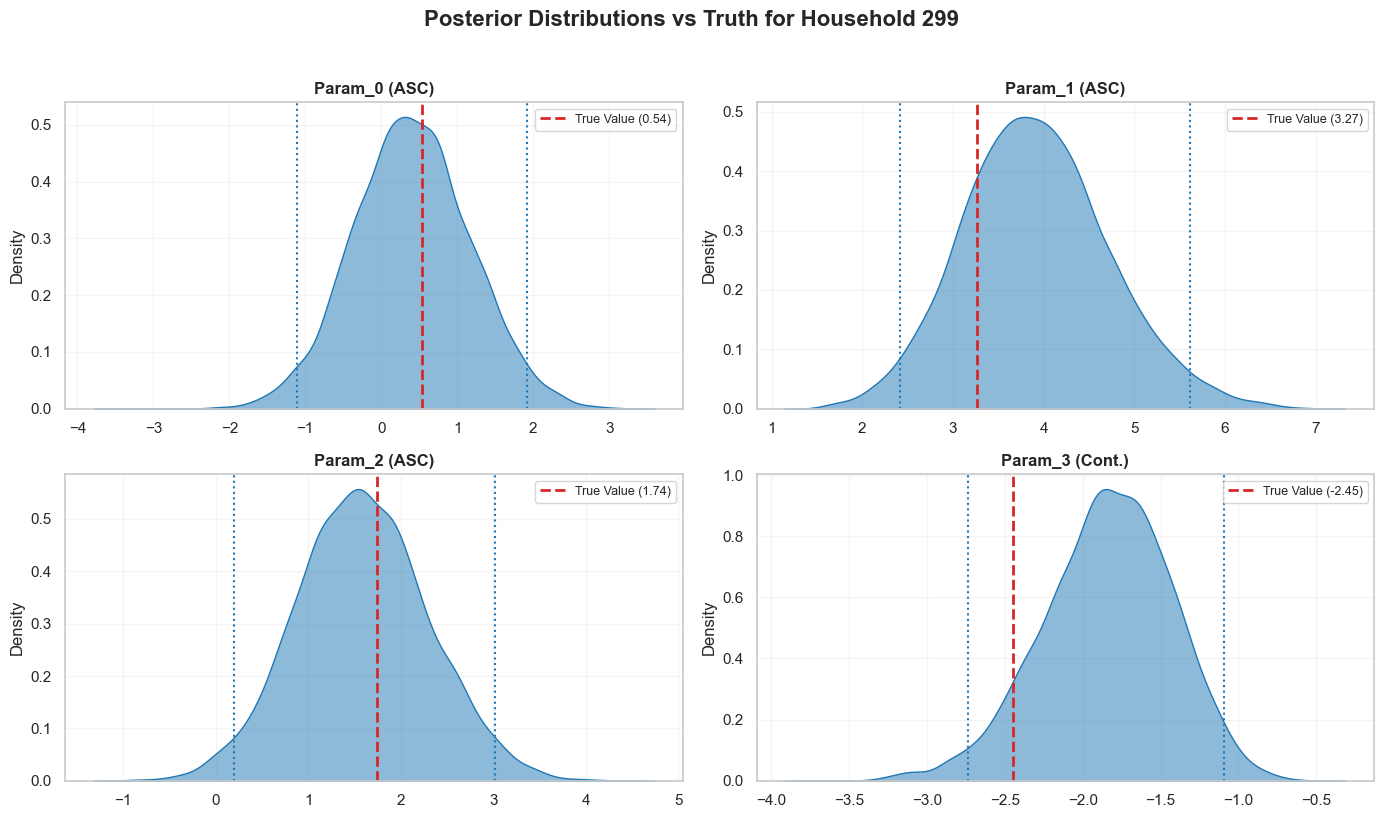

In [23]:
def plot_beta_distributions(
    samples, true_vals, p_names, title_prefix,
    color_l="#1f77b4", color_t="#d62728"
):
    cols = 2
    rows = int(np.ceil(len(p_names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    if len(p_names) == 1: axes = np.array([axes])

    for i, (ax, param) in enumerate(zip(axes.flatten(), p_names)):
        if i >= len(p_names):
            ax.axis("off"); continue
        l_vals = samples[:, i]
        t_val  = true_vals[i]
        ci_low, ci_high = np.percentile(l_vals, [2.5, 97.5])
        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.5)
        ax.axvline(ci_low,  color=color_l, linestyle=":", lw=1.5)
        ax.axvline(ci_high, color=color_l, linestyle=":", lw=1.5)
        ax.axvline(t_val,   color=color_t, linestyle="--", lw=2,
                   label=f"True Value ({t_val:.2f})")
        ax.set_title(param, fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.2)
        ax.legend(loc="upper right", fontsize=9)

    plt.suptitle(title_prefix, y=1.02, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Plotting Household-Level Distributions...")
plot_beta_distributions(
    liesel_beta_full[:, 0, :], true_betas[0, :],
    param_names, "Posterior Distributions vs Truth for Household 0"
)
plot_beta_distributions(
    liesel_beta_full[:, -1, :], true_betas[-1, :],
    param_names, f"Posterior Distributions vs Truth for Household {n_units_-1}"
)


Recovering and plotting covariance matrices (Sigma_k)  [post relabeling]...


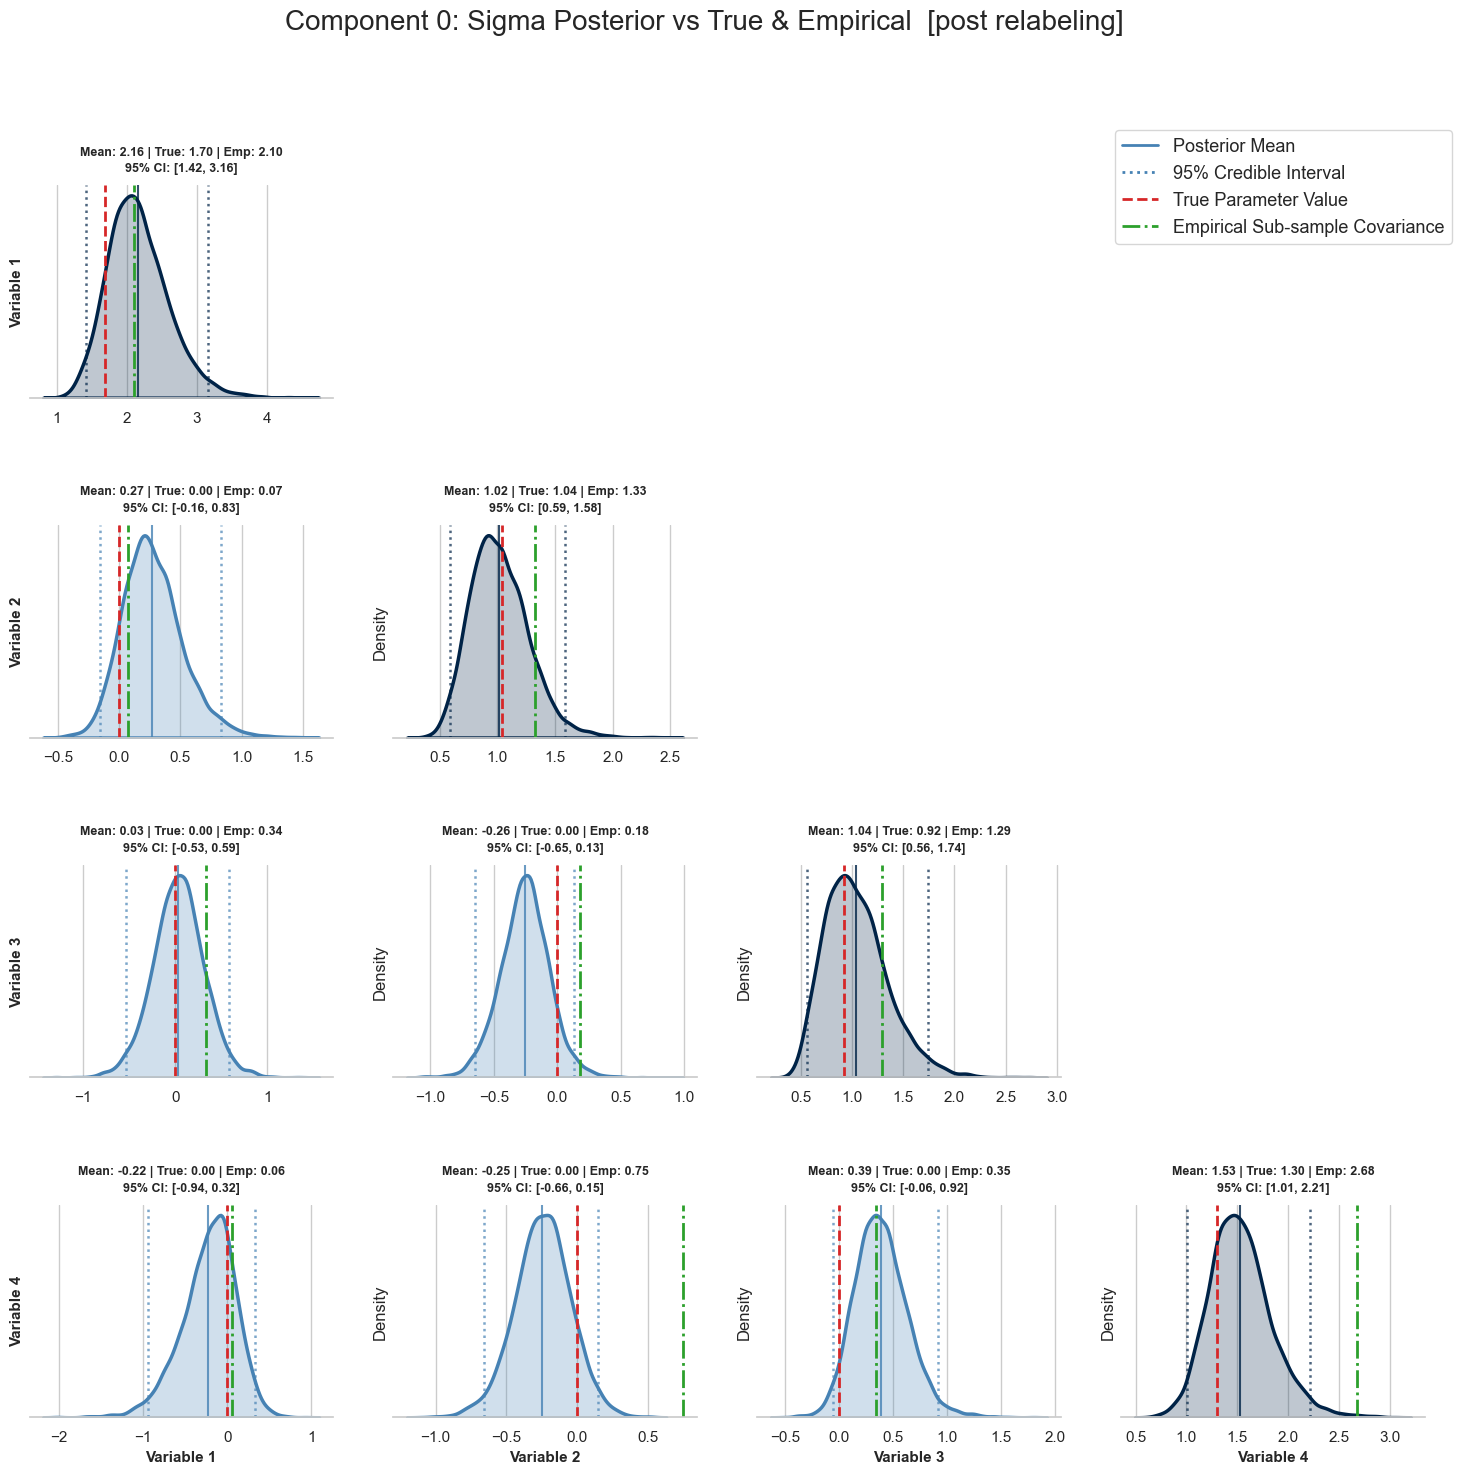

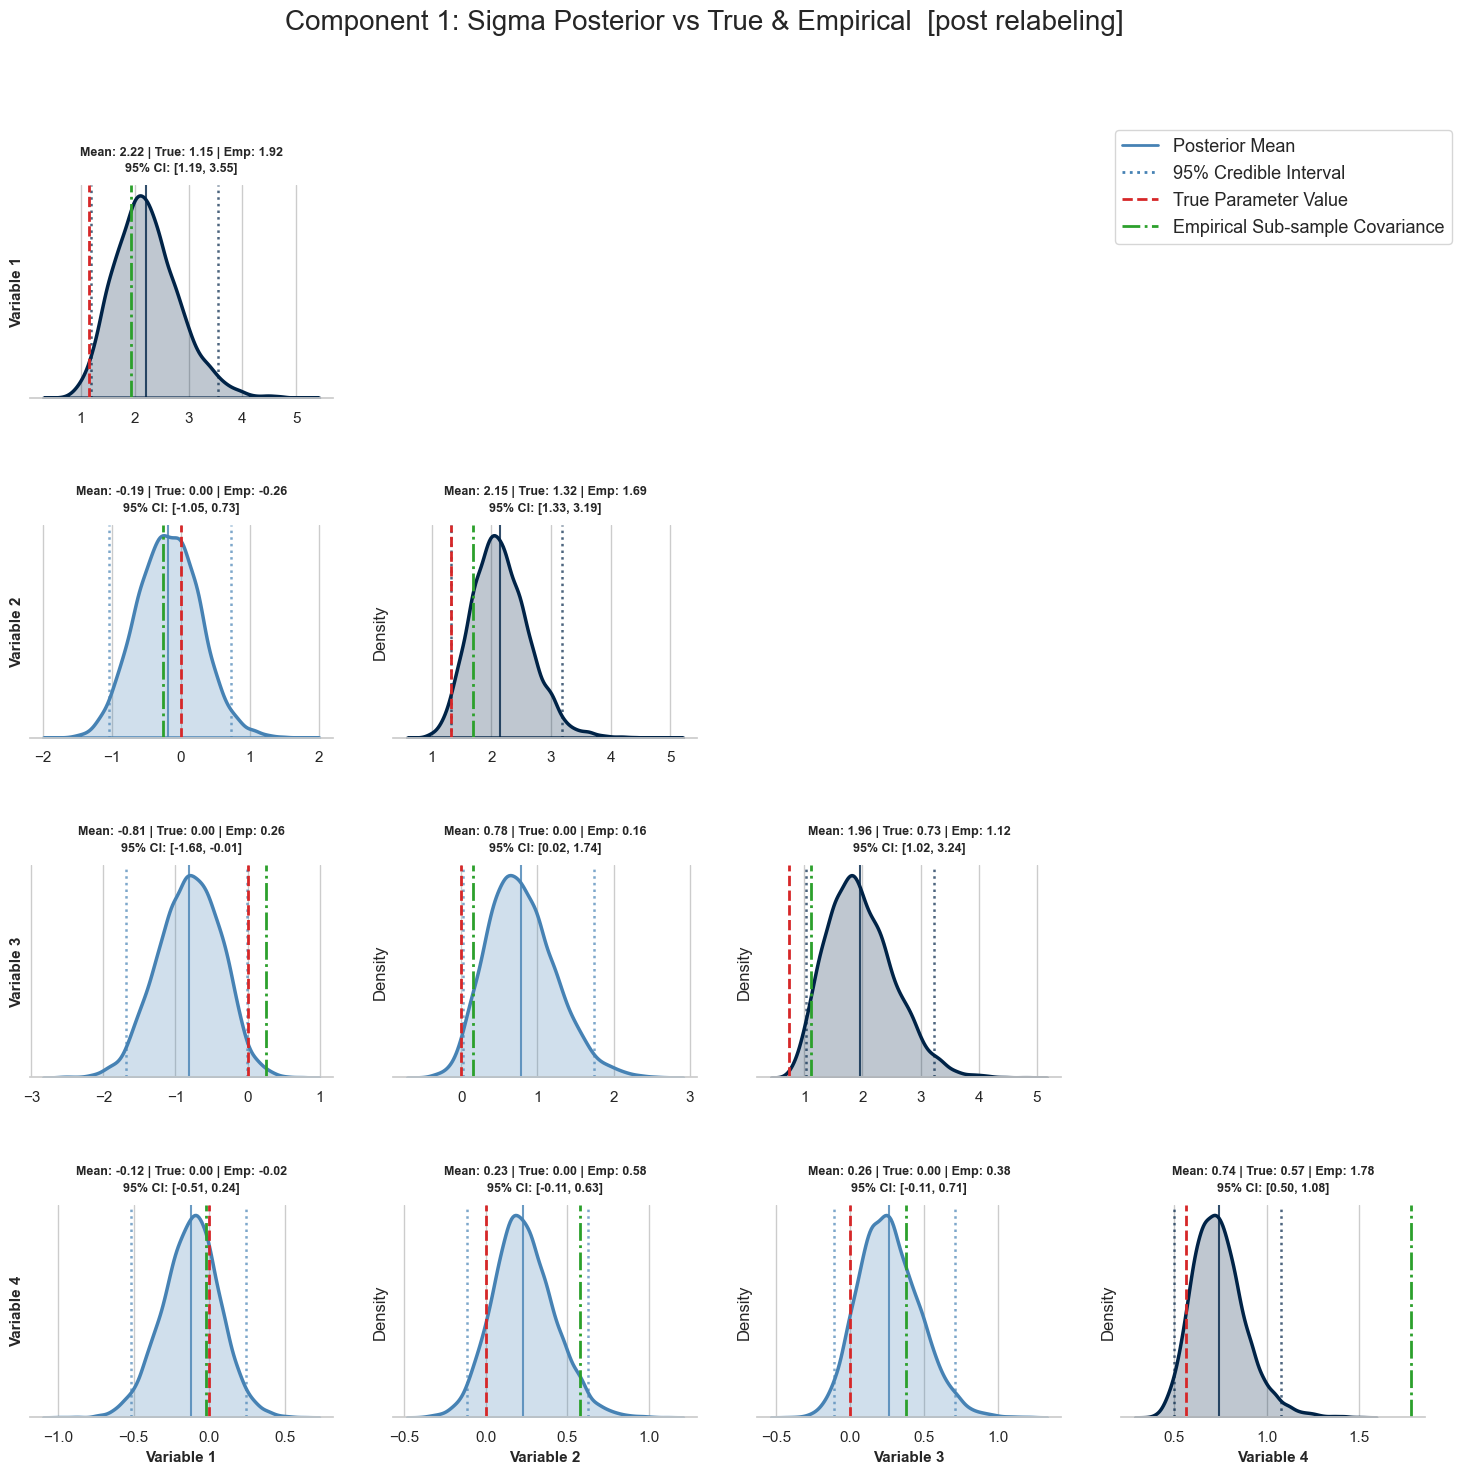

: 

In [ ]:
def plot_covariance_relabeled(
    sigma_rl, true_sigma=None, empirical_sigma=None,
    component_idx=0, figsize=(18, 16)
):
    """
    Lower-triangular grid of posterior KDE plots for Sigma_k[component_idx].
    Uses relabeled sigma samples from pp['sigma_k'].
    """
    samples = sigma_rl[:, component_idx]   # (n_draws, P, P)
    n_dim   = samples.shape[-1]

    diag_color     = "#002347"
    off_diag_color = "#4682B4"
    true_color     = "#D62728"
    emp_color      = "#2CA02C"

    fig, axes = plt.subplots(n_dim, n_dim, figsize=figsize)

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis("off"); continue

            data_vec = samples[:, i, j]
            color    = diag_color if i == j else off_diag_color
            pm       = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])

            sns.kdeplot(data_vec, ax=ax, fill=True, color=color,
                        alpha=0.25, lw=2.5)
            ax.axvline(pm,      color=color, linestyle="-",  lw=1.5, alpha=0.8)
            ax.axvline(ci_low,  color=color, linestyle=":",  lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=color, linestyle=":",  lw=1.8, alpha=0.7)

            title_parts = [f"Mean: {pm:.2f}"]
            if true_sigma is not None:
                tv = true_sigma[i, j]
                ax.axvline(tv, color=true_color, linestyle="--", lw=2)
                title_parts.append(f"True: {tv:.2f}")
            if empirical_sigma is not None:
                ev = empirical_sigma[i, j]
                ax.axvline(ev, color=emp_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {ev:.2f}")

            ax.set_title(
                " | ".join(title_parts) +
                f"\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]",
                fontsize=9, pad=10, linespacing=1.5, fontweight="bold"
            )
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=11, fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=11, fontweight="bold")

    legend_elements = [
        Line2D([0],[0], color=off_diag_color, linestyle="-",  lw=2, label="Posterior Mean"),
        Line2D([0],[0], color=off_diag_color, linestyle=":",  lw=2, label="95% Credible Interval"),
        Line2D([0],[0], color=true_color,     linestyle="--", lw=2, label="True Parameter Value"),
        Line2D([0],[0], color=emp_color,       linestyle="-.", lw=2, label="Empirical Sub-sample Covariance"),
    ]
    fig.legend(handles=legend_elements, loc="upper right",
               bbox_to_anchor=(0.92, 0.92), fontsize=13)
    plt.suptitle(
        f"Component {component_idx}: Sigma Posterior vs True & Empirical"
        f"  [post relabeling]",
        fontsize=20, y=0.99, fontweight="light"
    )
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()


print("Recovering and plotting covariance matrices (Sigma_k)  [post relabeling]...")
for k in range(K):
    comp_mask  = choice_data["TRUE_INDICATORS"] == k
    comp_betas = choice_data["TRUE_BETA"][comp_mask]
    emp_sigma  = np.cov(comp_betas, rowvar=False) if len(comp_betas) > 1 else None

    plot_covariance_relabeled(
        sigma_rl        = sigma_samples,
        true_sigma      = choice_data["TRUE_SIGMA_K"][k],
        empirical_sigma = emp_sigma,
        component_idx   = k,
    )
